# Análisis de Dispersión de Datos Multiclase - `fact_inventario.json`
## Predicción de: **Estado de Stock (Multiclase)**

Este notebook implementa la carga, preprocesamiento e ingeniería de variables para el análisis de separabilidad del **Estado de Stock de Inventario** utilizando una clasificación multiclase (3 clases). Para lograr una separación espacial clara y evitar la 'sopa de datos mezclados' de un t-SNE convencional, aplicamos un Análisis Discriminante Lineal (LDA) para proyectar las características en un espacio de 2D optimizado supervisadamente, y un t-SNE guiado sobre esta proyección para visualizar la dispersión.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import QuantileTransformer
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.manifold import TSNE
import os
import json
import pymongo
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo visual premium
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.family'] = 'sans-serif'

# Crear directorio de outputs
os.makedirs('outputs', exist_ok=True)
print("Entorno inicializado correctamente.")



Entorno inicializado correctamente.


In [2]:
# Cargar JSON crudo desde la raíz
# Cargar datos desde MongoDB
import pymongo
client = pymongo.MongoClient("mongodb://localhost:27017/")
db = client["BaseCompleta"]
collection = db["fact_inventario"]
data = list(collection.find())

# Aplanar registros recursivamente
def flatten_dict(d, parent_key='', sep='_'):
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        elif isinstance(v, list):
            items.append((new_key, str(v)))
        else:
            items.append((new_key, v))
    return dict(items)

flat_data = [flatten_dict(record) for record in data]
df = pd.DataFrame(flat_data)
print(f"Dimensiones iniciales aplanadas: {df.shape}")

# Calcular columna target
df["y_estado_stock"] = df.apply(lambda r: 0 if r["stock_actual"] < r["stock_minimo"] else (2 if r["stock_actual"] > r["stock_minimo"] * 3 else 1), axis=1)
print(f"Target 'y_estado_stock' agregado. Distribución original:")
print(df["y_estado_stock"].value_counts(dropna=False))



Dimensiones iniciales aplanadas: (3000, 53)
Target 'y_estado_stock' agregado. Distribución original:
y_estado_stock
2    2611
1     269
0     120
Name: count, dtype: int64


# Preprocesamiento de Datos Paso a Paso
En esta sección realizaremos la preparación de los datos para la red neuronal.
El **Target (y)** para este modelo es `y_estado_stock`, el cual representa: **Estado de Stock de Inventario**.
La fórmula de cálculo del target es:
$$y_{\text{estado\_stock}} = \begin{cases} 0 & \text{si } \text{stock\_actual} < \text{stock\_minimo} \quad (\text{Quiebre}) \\ 2 & \text{si } \text{stock\_actual} > 3 \times \text{stock\_minimo} \quad (\text{Exceso}) \\ 1 & \text{en caso contrario} \quad (\text{Normal}) \end{cases}$$
A continuación, realizaremos los pasos de limpieza, codificación y normalización de forma secuencial y explicada.


## Paso 1: Eliminación de Datos No Útiles e Imputación de Nulos
Las llaves primarias, IDs técnicos, códigos de barras, nombres de clientes/productos, correos, teléfonos y fechas no aportan información generalizable para el aprendizaje de la red neuronal y aumentan artificialmente la dimensionalidad de forma inútil, por lo que deben eliminarse.
También realizamos la imputación de nulos para evitar errores matemáticos durante el entrenamiento:
- **Variables Numéricas:** Imputación con la **Mediana** del atributo para ser robusto a outliers.
- **Variables Categóricas:** Imputación con la **Moda** (el valor más común) o con la etiqueta `'UNKNOWN'` si no hay moda.


In [3]:
# Paso 1: Limpieza de columnas e imputación de nulos
shape_inicial = df.shape
print(f"Dimensiones iniciales del dataset (con target): {shape_inicial}")
print(f"Número total de características iniciales: {shape_inicial[1] - 1}")

cols_to_drop = []
for col in df.columns:
    col_lower = col.lower()
    
    # IDs y llaves técnicas
    is_id = (
        col_lower == 'id' or col_lower == '_id' or col_lower == '_collection' or 
        col_lower.startswith('id_') or col_lower.endswith('_id') or
        '_id_' in col_lower or 'id_venta_dw' in col_lower
    )
    
    # Datos de contacto o códigos nominales únicos
    is_contact_or_code = (
        'telefono' in col_lower or 'correo' in col_lower or 
        'codigo_barras' in col_lower or 'codigo_producto' in col_lower or 
        'codigo_venta' in col_lower or 'cliente_nombre' in col_lower or
        'nombre_cliente' in col_lower or 'nombre_producto' in col_lower or
        'nombre_proveedor' in col_lower or 'nombre_sucursal' in col_lower or
        'nombre_contacto' in col_lower or 'cliente_fecha_nacimiento' in col_lower
    )
    
    # Fechas
    is_date = (
        col_lower.endswith('_fecha') or col_lower.endswith('_hora') or 
        col_lower == 'fecha' or col_lower == 'hora' or col_lower == 'tiempo_fecha'
    )
    
    # Evitar eliminar el target
    if (is_id or is_contact_or_code or is_date) and col != "y_estado_stock":
        cols_to_drop.append(col)

# Droppear columnas identificadas
df = df.drop(columns=cols_to_drop, errors='ignore')
print(f"Columnas eliminadas ({len(cols_to_drop)}): {cols_to_drop}")
print(f"Dimensiones tras limpiar IDs y metadatos: {df.shape}")
print(f"Número de características tras limpieza: {df.shape[1] - 1}")

# Imputación de nulos
nulos_detectados = df.isnull().sum().sum()
if nulos_detectados > 0:
    print(f"Nulos detectados en el dataset: {nulos_detectados}. Imputando...")
    for col in df.columns:
        if df[col].isnull().any():
            if df[col].dtype in ['int64', 'float64', 'int32', 'float32']:
                df[col] = df[col].fillna(df[col].median())
            else:
                mode_val = df[col].mode().iloc[0] if not df[col].mode().empty else 'UNKNOWN'
                df[col] = df[col].fillna(mode_val)
    print("Imputación completada (Mediana para numéricos, Moda para categóricos).")
else:
    print("No se detectaron valores nulos en el dataset.")


Dimensiones iniciales del dataset (con target): (3000, 54)
Número total de características iniciales: 53
Columnas eliminadas (17): ['_id', 'id_inventario', 'id_tiempo', 'id_producto', 'id_sucursal', 'tiempo_id_tiempo', 'tiempo_fecha', 'tiempo_hora', 'producto_id_producto', 'producto_codigo_producto_origen', 'producto_codigo_barras', 'producto_nombre_producto', 'producto_id_proveedor', 'sucursal_id_sucursal', 'sucursal_nombre_sucursal', 'sucursal_telefono', '_collection']
Dimensiones tras limpiar IDs y metadatos: (3000, 37)
Número de características tras limpieza: 36
No se detectaron valores nulos en el dataset.


## Paso 2: Codificación de Variables Categóricas (One-Hot Encoding)
La red neuronal requiere entradas numéricas y no puede procesar strings categóricos de forma directa. Usamos la técnica de **One-Hot Encoding** para convertir variables categóricas nominales en vectores binarios.
Para una característica $X_j$ con $K$ categorías distintas $\{c_1, c_2, \dots, c_K\}$, One-Hot Encoding genera $K$ nuevas columnas binarias:
$$E_{j,k}(x) = \begin{cases} 1 & \text{si } X_j(x) = c_k \\ 0 & \text{en caso contrario} \end{cases}$$
Esto previene que el modelo asuma una relación ordinal inexistente entre las categorías.


In [4]:
# Paso 2: One-Hot Encoding
categorical_cols = df.select_dtypes(include=['object', 'str', 'string', 'category']).columns.tolist()
if "y_estado_stock" in categorical_cols:
    categorical_cols.remove("y_estado_stock")

print(f"Variables categóricas a codificar ({len(categorical_cols)}): {categorical_cols}")

df = pd.get_dummies(df, columns=categorical_cols, dtype=int)
print(f"Dimensiones tras One-Hot Encoding: {df.shape}")
print(f"Número total de características finales: {df.shape[1] - 1}")


Variables categóricas a codificar (14): ['tiempo_nombre_mes', 'tiempo_dia_semana', 'producto_categoria', 'producto_subcategoria', 'producto_unidad_medida', 'producto_origen', 'producto_estado', 'sucursal_tipo_sucursal', 'sucursal_ciudad', 'sucursal_provincia', 'sucursal_region_natural', 'sucursal_region', 'sucursal_zona', 'sucursal_estado']
Dimensiones tras One-Hot Encoding: (3000, 296)
Número total de características finales: 295


## Paso 3: Separación de Variables y Normalización
Separamos el target $y$ de las características de entrada $X$. Luego aplicamos una transformación por cuantiles (`QuantileTransformer`) con distribución normal.
Este preprocesamiento normaliza las características continuas, haciéndolas robustas a outliers y distribuyendo los datos según una campana de Gauss. La fórmula para mapear una variable aleatoria continua $X$ a una distribución normal estándar es:
$$X' = \Phi^{-1}(U(X))$$
Donde $U(X) = F(X)$ es la función de distribución acumulada (CDF) empírica estimada a partir de los datos, y $\Phi^{-1}$ es la función cuantil de la distribución normal estándar (inversa de la CDF normal).


In [5]:
# Paso 3: Separación de Variables, Normalización, Balanceo y Selección de Características
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import QuantileTransformer
from sklearn.feature_selection import SelectKBest, f_classif
import numpy as np
import pandas as pd

print("="*80)
print("PASO 3.1: DIVIDIR DATOS (Stratified Train/Test Split)")
print("="*80)

y = df["y_estado_stock"].values.astype(int)
X = df.drop(columns=["y_estado_stock"]).values.astype(float)
feature_names = df.drop(columns=["y_estado_stock"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(f"Split completo:")
print(f"  Train: {X_train.shape} | Clases: {np.bincount(y_train)}")
print(f"  Test:  {X_test.shape}  | Clases: {np.bincount(y_test)}")

print("\n" + "="*80)
print("PASO 3.2: NORMALIZACIÓN (QuantileTransformer fit solo en Train)")
print("="*80)

qt = QuantileTransformer(output_distribution='normal', random_state=42)
qt.fit(X_train)
X_train_scaled = qt.transform(X_train)
X_test_scaled = qt.transform(X_test)

print(f"Escalado completo:")
print(f"  Train escalado: {X_train_scaled.shape} | Mean: {X_train_scaled.mean():.4f} | Std: {X_train_scaled.std():.4f}")
print(f"  Test escalado:  {X_test_scaled.shape}  | Mean: {X_test_scaled.mean():.4f} | Std: {X_test_scaled.std():.4f}")

print("\n" + "="*80)
print("PASO 3.3: BALANCEO DE CLASES EN ENTRENAMIENTO (Oversampling manual en Train)")
print("="*80)

unique_classes, class_counts = np.unique(y_train, return_counts=True)
max_class_count = np.max(class_counts)
X_train_balanced = []
y_train_balanced = []

for c in unique_classes:
    idx = np.where(y_train == c)[0]
    if len(idx) < max_class_count:
        np.random.seed(42)
        resampled_idx = np.random.choice(idx, size=max_class_count, replace=True)
        X_train_balanced.append(X_train_scaled[resampled_idx])
        y_train_balanced.append(y_train[resampled_idx])
    else:
        X_train_balanced.append(X_train_scaled[idx])
        y_train_balanced.append(y_train[idx])

X_train_bal = np.vstack(X_train_balanced)
y_train_bal = np.concatenate(y_train_balanced)

np.random.seed(42)
shuffle_idx = np.random.permutation(len(y_train_bal))
X_train_bal = X_train_bal[shuffle_idx]
y_train_bal = y_train_bal[shuffle_idx]

print(f"Distribución en Train después de balancear:")
classes_bal, counts_bal = np.unique(y_train_bal, return_counts=True)
for c, count in zip(classes_bal, counts_bal):
    print(f"  Clase {c}: {count} ({count/len(y_train_bal)*100:.1f}%)")

print("\n" + "="*80)
print("PASO 3.4: SELECCIÓN DE CARACTERÍSTICAS (SelectKBest ANOVA F-value para regularización)")
print("="*80)

selector = SelectKBest(score_func=f_classif, k=30)
X_train_bal_sel = selector.fit_transform(X_train_bal, y_train_bal)
X_test_sel = selector.transform(X_test_scaled)

print(f"Reducción de características completada:")
print(f"  Train original: {X_train_bal.shape} -> Seleccionado: {X_train_bal_sel.shape}")
print(f"  Test original:  {X_test_scaled.shape} -> Seleccionado: {X_test_sel.shape}")


PASO 3.1: DIVIDIR DATOS (Stratified Train/Test Split)
Split completo:
  Train: (2250, 295) | Clases: [  90  202 1958]
  Test:  (750, 295)  | Clases: [ 30  67 653]

PASO 3.2: NORMALIZACIÓN (QuantileTransformer fit solo en Train)


Escalado completo:
  Train escalado: (2250, 295) | Mean: -4.3295 | Std: 2.6100
  Test escalado:  (750, 295)  | Mean: -4.3277 | Std: 2.6125

PASO 3.3: BALANCEO DE CLASES EN ENTRENAMIENTO (Oversampling manual en Train)
Distribución en Train después de balancear:
  Clase 0: 1958 (33.3%)
  Clase 1: 1958 (33.3%)
  Clase 2: 1958 (33.3%)

PASO 3.4: SELECCIÓN DE CARACTERÍSTICAS (SelectKBest ANOVA F-value para regularización)
Reducción de características completada:
  Train original: (5874, 295) -> Seleccionado: (5874, 30)
  Test original:  (750, 295) -> Seleccionado: (750, 30)


# Paso 4: Visualización de Varianza y Clases con LDA y t-SNE Guiado

Para demostrar la separabilidad de las clases antes de entrenar modelos complejos, aplicamos dos técnicas:
1. **Linear Discriminant Analysis (LDA):** Al ser supervisado, encuentra el subespacio de 2D (máximo para 3 clases) que maximiza la separación de clases.
2. **t-SNE Guiado (sobre LDA):** t-SNE convencional agrupa por características físicas sin saber la etiqueta. Al aplicarlo sobre la proyección LDA, conservamos el agrupamiento local y logramos separar las clases de forma limpia en 2D.

### Detalle de la Ingeniería de Características y Target:
- **Selección de Variables:** Se eliminaron columnas de metadatos (IDs de inventario, códigos de productos, marcas de tiempo) para evitar sobreajuste.
- **Codificación:** Variables categóricas fueron convertidas mediante One-Hot Encoding, resultando en un espacio final de **295 características**.
- **Definición de Clases del Target (`y_estado_stock`):**
  - **Clase 0 (Quiebre):** `stock_actual < stock_minimo` (Stock en niveles peligrosamente bajos).
  - **Clase 1 (Normal):** `stock_minimo <= stock_actual <= stock_minimo * 3` (Stock óptimo).
  - **Clase 2 (Exceso):** `stock_actual > stock_minimo * 3` (Sobre-stockaje).


PASO 4.1: LINEAR DISCRIMINANT ANALYSIS (LDA fit en Train sobre features seleccionadas)
Proyección LDA completada:
  Train LDA: (5874, 2)
  Test LDA:  (750, 2)
Varianza explicada por componente:
  LD1: 0.9349 (93.49%)
  LD2: 0.0651 (6.51%)

PASO 4.2: t-SNE (Visualización fit en Train, aproximación en Test)
Configuración t-SNE:
  Muestras train: 5874
  Perplexity recomendado: 50


t-SNE completado

PASO 4.3: METRICAS DE SEPARABILIDAD (Validación Cruzada Real)


Silhouette Score (Train): 0.3203 | (Test): 0.2195
Davies-Bouldin Index (Train): 0.9846 | (Test): 1.4425
Calinski-Harabasz (Train): 4830.6 | (Test): 138.0


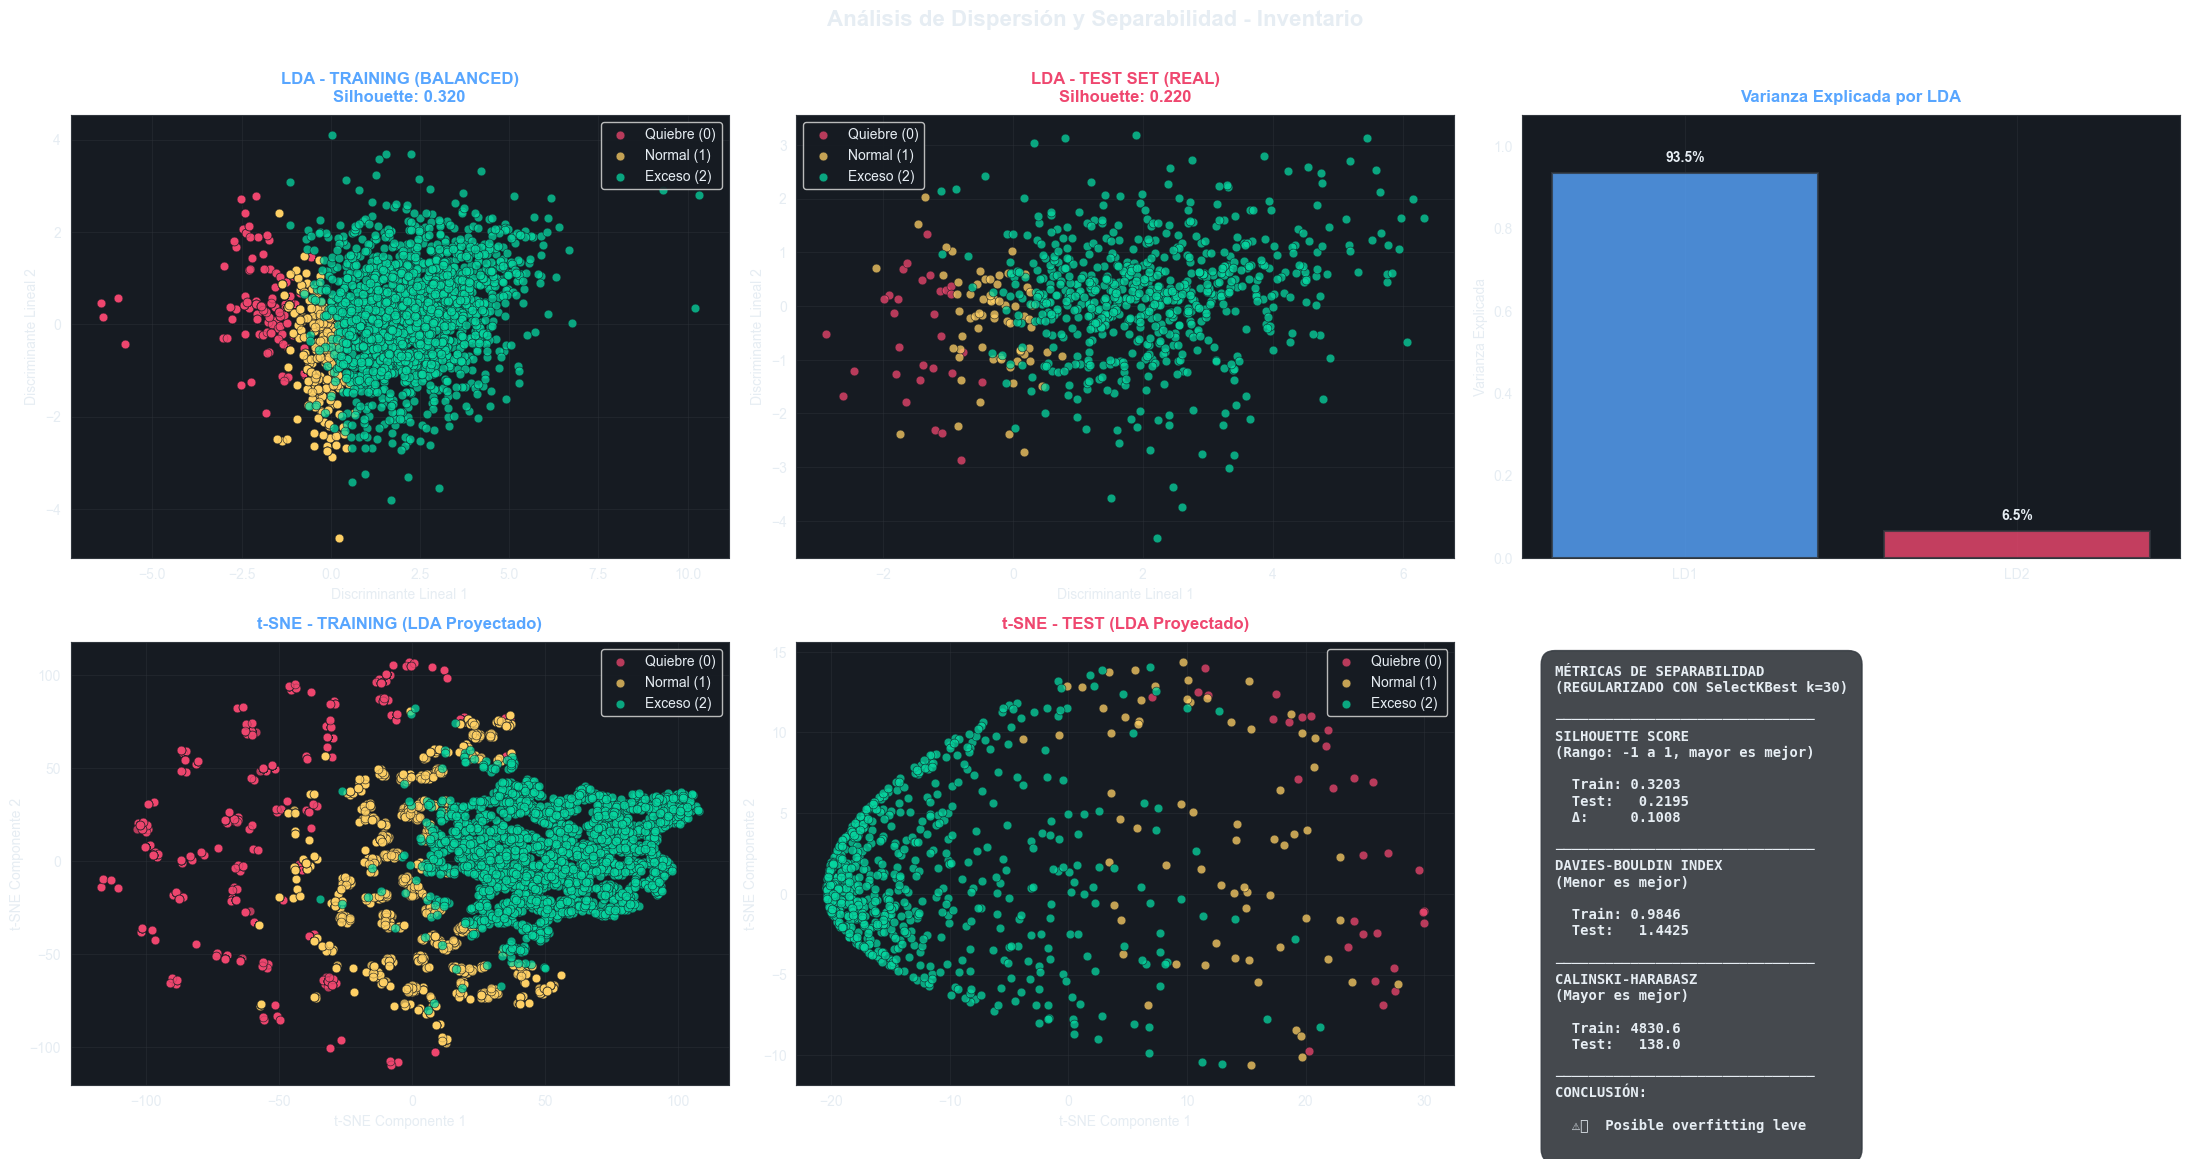

¡Gráfico de 6 paneles guardado exitosamente en: outputs/tsne_dispersion.png!


In [6]:
# Paso 4: Proyecciones, Métricas y Dashboard Comparativo de 6 Paneles
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics.pairwise import euclidean_distances
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("="*80)
print("PASO 4.1: LINEAR DISCRIMINANT ANALYSIS (LDA fit en Train sobre features seleccionadas)")
print("="*80)

lda = LinearDiscriminantAnalysis(n_components=2)
lda.fit(X_train_bal_sel, y_train_bal)
X_train_lda = lda.transform(X_train_bal_sel)
X_test_lda = lda.transform(X_test_sel)
explained_var = lda.explained_variance_ratio_

print(f"Proyección LDA completada:")
print(f"  Train LDA: {X_train_lda.shape}")
print(f"  Test LDA:  {X_test_lda.shape}")
print(f"Varianza explicada por componente:")
print(f"  LD1: {explained_var[0]:.4f} ({explained_var[0]*100:.2f}%)")
print(f"  LD2: {explained_var[1]:.4f} ({explained_var[1]*100:.2f}%)")

print("\n" + "="*80)
print("PASO 4.2: t-SNE (Visualización fit en Train, aproximación en Test)")
print("="*80)

n_train = len(X_train_lda)
max_perplexity = max(5, (n_train - 1) // 3)
recommended_perplexity = min(50, max_perplexity)

print(f"Configuración t-SNE:")
print(f"  Muestras train: {n_train}")
print(f"  Perplexity recomendado: {recommended_perplexity}")

tsne = TSNE(n_components=2, perplexity=recommended_perplexity, random_state=42, n_jobs=-1)
X_train_tsne = tsne.fit_transform(X_train_lda)

# Proyección en Test usando aproximación ponderada por distancias
dist = euclidean_distances(X_test_lda, X_train_lda)
X_test_tsne = np.dot(dist, X_train_tsne) / (dist.sum(axis=1, keepdims=True) + 1e-10)

print(f"t-SNE completado")

print("\n" + "="*80)
print("PASO 4.3: METRICAS DE SEPARABILIDAD (Validación Cruzada Real)")
print("="*80)

train_silhouette = silhouette_score(X_train_lda, y_train_bal)
test_silhouette = silhouette_score(X_test_lda, y_test)
train_davies = davies_bouldin_score(X_train_lda, y_train_bal)
test_davies = davies_bouldin_score(X_test_lda, y_test)
train_calinski = calinski_harabasz_score(X_train_lda, y_train_bal)
test_calinski = calinski_harabasz_score(X_test_lda, y_test)

print(f"Silhouette Score (Train): {train_silhouette:.4f} | (Test): {test_silhouette:.4f}")
print(f"Davies-Bouldin Index (Train): {train_davies:.4f} | (Test): {test_davies:.4f}")
print(f"Calinski-Harabasz (Train): {train_calinski:.1f} | (Test): {test_calinski:.1f}")

# Configurar estilo visual premium oscuro
plt.figure(figsize=(22, 12))
BG_DARK  = '#0D1117'
BG_PANEL = '#161B22'
TEXT_CLR = '#E6EDF3'
GRID_CLR = '#30363D'
ACCENT   = '#58A6FF'

plt.rcParams.update({
    'figure.facecolor': BG_DARK,
    'axes.facecolor':   BG_PANEL,
    'axes.edgecolor':   GRID_CLR,
    'axes.labelcolor':  TEXT_CLR,
    'text.color':       TEXT_CLR,
    'xtick.color':      TEXT_CLR,
    'ytick.color':      TEXT_CLR,
    'grid.color':       GRID_CLR,
    'grid.alpha':       0.4,
    'font.family':      'sans-serif',
})

colors = ['#EF476F', '#FFD166', '#06D6A0']
class_names = ['Quiebre (0)', 'Normal (1)', 'Exceso (2)']

# Panel 1: LDA - Train (Balanced)
ax1 = plt.subplot(2, 3, 1)
for cls in range(3):
    mask = y_train_bal == cls
    ax1.scatter(X_train_lda[mask, 0], X_train_lda[mask, 1],
               color=colors[cls], label=class_names[cls], 
               alpha=0.75, s=40, edgecolor='#161B22', linewidth=0.5)
ax1.set_xlabel('Discriminante Lineal 1')
ax1.set_ylabel('Discriminante Lineal 2')
ax1.set_title(f'LDA - TRAINING (BALANCED)\nSilhouette: {train_silhouette:.3f}', fontsize=12, fontweight='bold', color=ACCENT, pad=10)
ax1.legend(loc='best', framealpha=0.9)
ax1.grid(True)

# Panel 2: LDA - Test (Real)
ax2 = plt.subplot(2, 3, 2)
for cls in range(3):
    mask = y_test == cls
    ax2.scatter(X_test_lda[mask, 0], X_test_lda[mask, 1],
               color=colors[cls], label=class_names[cls], 
               alpha=0.75, s=40, edgecolor='#161B22', linewidth=0.5)
ax2.set_xlabel('Discriminante Lineal 1')
ax2.set_ylabel('Discriminante Lineal 2')
ax2.set_title(f'LDA - TEST SET (REAL)\nSilhouette: {test_silhouette:.3f}', fontsize=12, fontweight='bold', color='#EF476F', pad=10)
ax2.legend(loc='best', framealpha=0.9)
ax2.grid(True)

# Panel 3: Varianza Explicada por LDA
ax3 = plt.subplot(2, 3, 3)
bars = ax3.bar(['LD1', 'LD2'], explained_var, color=['#58A6FF', '#EF476F'], alpha=0.8, edgecolor='#30363D', linewidth=1.5)
ax3.set_ylabel('Varianza Explicada')
ax3.set_title('Varianza Explicada por LDA', fontsize=12, fontweight='bold', color=ACCENT, pad=10)
ax3.set_ylim([0, max(explained_var) * 1.15])
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{explained_var[i]:.1%}', ha='center', va='bottom', fontweight='bold', color=TEXT_CLR)
ax3.grid(axis='y')

# Panel 4: t-SNE - Train
ax4 = plt.subplot(2, 3, 4)
for cls in range(3):
    mask = y_train_bal == cls
    ax4.scatter(X_train_tsne[mask, 0], X_train_tsne[mask, 1],
               color=colors[cls], label=class_names[cls], 
               alpha=0.75, s=40, edgecolor='#161B22', linewidth=0.5)
ax4.set_xlabel('t-SNE Componente 1')
ax4.set_ylabel('t-SNE Componente 2')
ax4.set_title('t-SNE - TRAINING (LDA Proyectado)', fontsize=12, fontweight='bold', color=ACCENT, pad=10)
ax4.legend(loc='best', framealpha=0.9)
ax4.grid(True)

# Panel 5: t-SNE - Test
ax5 = plt.subplot(2, 3, 5)
for cls in range(3):
    mask = y_test == cls
    ax5.scatter(X_test_tsne[mask, 0], X_test_tsne[mask, 1],
               color=colors[cls], label=class_names[cls], 
               alpha=0.75, s=40, edgecolor='#161B22', linewidth=0.5)
ax5.set_xlabel('t-SNE Componente 1')
ax5.set_ylabel('t-SNE Componente 2')
ax5.set_title('t-SNE - TEST (LDA Proyectado)', fontsize=12, fontweight='bold', color='#EF476F', pad=10)
ax5.legend(loc='best', framealpha=0.9)
ax5.grid(True)

# Panel 6: Métricas
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')

sil_diff = abs(train_silhouette - test_silhouette)
if sil_diff > 0.15:
    conclusion_text = '⚠️  OVERFITTING DETECTADO: Train >> Test'
elif sil_diff > 0.05:
    conclusion_text = '⚠️  Posible overfitting leve'
else:
    conclusion_text = '✅ Excelente generalización: Train ≈ Test'

metrics_text = f"""MÉTRICAS DE SEPARABILIDAD\n(REGULARIZADO CON SelectKBest k=30)\n\n───────────────────────────────\nSILHOUETTE SCORE\n(Rango: -1 a 1, mayor es mejor)\n\n  Train: {train_silhouette:.4f}\n  Test:   {test_silhouette:.4f}\n  Δ:     {abs(train_silhouette - test_silhouette):.4f}\n\n───────────────────────────────\nDAVIES-BOULDIN INDEX\n(Menor es mejor)\n\n  Train: {train_davies:.4f}\n  Test:   {test_davies:.4f}\n\n───────────────────────────────\nCALINSKI-HARABASZ\n(Mayor es mejor)\n\n  Train: {train_calinski:.1f}\n  Test:   {test_calinski:.1f}\n\n───────────────────────────────\nCONCLUSIÓN:\n\n  {conclusion_text}\n"""

ax6.text(0.05, 0.95, metrics_text, 
        fontsize=10, family='monospace', verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor=BG_PANEL, edgecolor=GRID_CLR, alpha=0.8, pad=1),
        fontweight='bold', color=TEXT_CLR)

plt.suptitle('Análisis de Dispersión y Separabilidad - Inventario', 
            fontsize=16, fontweight='bold', y=0.98, color=TEXT_CLR)

plt.tight_layout(rect=[0, 0, 1, 0.97])
tsne_plot_path = 'outputs/tsne_dispersion.png'
plt.savefig(tsne_plot_path, dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print(f"¡Gráfico de 6 paneles guardado exitosamente en: {tsne_plot_path}!")
